In [12]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('games.csv')

In [3]:
df.head()

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [4]:
df.columns = df.columns.str.lower()

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [6]:
df['year_of_release'] = df['year_of_release'].fillna(0)

In [7]:
df['year_of_release'].unique()

array([2006., 1985., 2008., 2009., 1996., 1989., 1984., 2005., 1999.,
       2007., 2010., 2013., 2004., 1990., 1988., 2002., 2001., 2011.,
       1998., 2015., 2012., 2014., 1992., 1997., 1993., 1994., 1982.,
       2016., 2003., 1986., 2000.,    0., 1995., 1991., 1981., 1987.,
       1980., 1983.])

In [8]:
df['year_of_release'] = df['year_of_release'].astype('int')

In [9]:
df['rating'].unique()

array(['E', nan, 'M', 'T', 'E10+', 'K-A', 'AO', 'EC', 'RP'], dtype=object)

In [10]:
df.insert(8, 'total_sales', df['na_sales']+df['eu_sales']+df['jp_sales']+df['other_sales'])

In [11]:
df.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,total_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,82.54,76.0,8,E
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,35.52,82.0,8.3,E
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,32.77,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,31.38,NaN,NaN,NaN


In [29]:
pivot_by_year = df[df['year_of_release']>0].pivot_table(index='year_of_release', values='name', aggfunc='count')

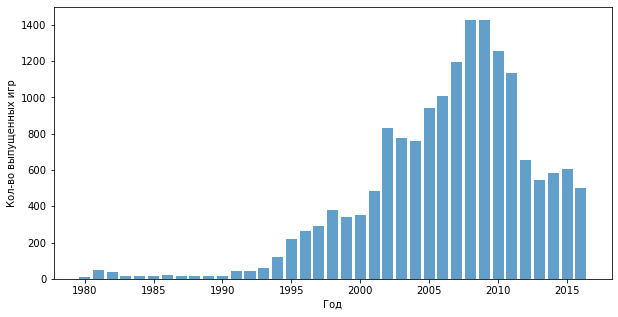

In [62]:
x=pivot_by_year.index
y=pivot_by_year['name']

plt.figure(figsize=(10,5))

plt.xlabel('Год')
plt.ylabel('Кол-во выпущенных игр')

plt.bar(x, y, alpha=0.7)
plt.show()

In [72]:
pivot_by_platform = df.pivot_table(index='platform', 
                                   values='total_sales', 
                                   aggfunc='sum').sort_values(by='total_sales', 
                                                                ascending=True).tail(20)

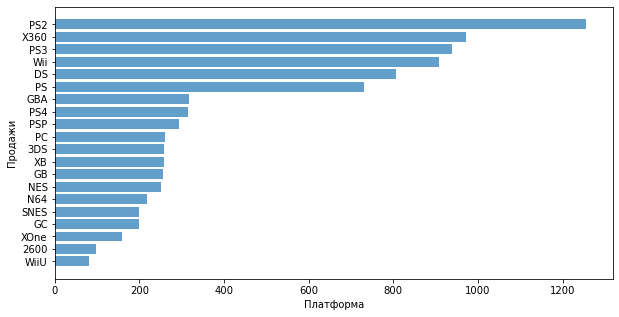

In [75]:
x=pivot_by_platform.index
y=pivot_by_platform['total_sales']

plt.figure(figsize=(10,5))

plt.xlabel('Платформа')
plt.ylabel('Продажи')

plt.barh(x, y, alpha=0.7)
plt.show()

In [82]:
top_platforms = list(pivot_by_platform.index)

In [83]:
top_platforms

['WiiU',
 '2600',
 'XOne',
 'GC',
 'SNES',
 'N64',
 'NES',
 'GB',
 'XB',
 '3DS',
 'PC',
 'PSP',
 'PS4',
 'GBA',
 'PS',
 'DS',
 'Wii',
 'PS3',
 'X360',
 'PS2']

In [99]:
each_platform_pivot_by_year = df[(df['platform']=='PS2')&(df['year_of_release']>0)].pivot_table(index=['platform','year_of_release'], 
                                                                  values='total_sales', 
                                                                  aggfunc='sum')

total_sales
platform year_of_release             
PS2      2000                   39.17
         2001                  166.43
         2002                  205.38
         2003                  184.31
         2004                  211.81
         2005                  160.66
         2006                  103.42
         2007                   75.99
         2008                   53.90
         2009                   26.40
         2010                    5.64
         2011                    0.45

In [ ]:
x=each_platform_pivot_by_year['year_of_release']
y=pivot_by_year['name']

plt.figure(figsize=(10,5))

plt.xlabel('Год')
plt.ylabel('Кол-во выпущенных игр')

plt.bar(x, y, alpha=0.7)
plt.show()